## Introduction

The dataset was provided by an online learning platform that contains information about students enrolled in courses in 2024 and records geographic, demographic, and behavioral data, so that this data can later be used to create a model that can predict student dropout in online courses.

## Preparation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection  import StratifiedKFold, train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import roc_auc_score, roc_curve, recall_score, f1_score, accuracy_score,precision_score, confusion_matrix
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree             import DecisionTreeClassifier
#import lightgbm

from IPython.display import display

In [2]:
# Download Datasets
path = r"C:\Users\Pablo\Documents\Data_projects\2603_predictive_model_students_dropout\student_dropout_dataset.csv"
df = pd.read_csv(path)

In [3]:
# Visualize dataframe information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [4]:
# Show dataframe first rows
print(df.head())

  student_id  age      region enroll_date  exam_season  courses_enrolled  \
0   STU00001   26  Alexandria  2024-01-13            0                 3   
1   STU00002   23       Amman  2024-05-05            0                 6   
2   STU00003   17       Dubai  2024-03-12            0                 3   
3   STU00004   23  Alexandria  2024-12-12            0                 6   
4   STU00005   20     Baghdad  2024-02-14            0                 5   

   completed_assignments  completion_rate  login_frequency  \
0                      5           0.3571             5.29   
1                      0           0.0000             0.84   
2                      1           0.0435             1.79   
3                     13           0.4396             0.78   
4                      5           0.2078             0.92   

   last_activity_days_ago  forum_posts_count  dropout_score  label  \
0                      10                  5         0.1064      0   
1                       7     

In [5]:
# Show dataframe last rows
print(df.tail())

     student_id  age      region enroll_date  exam_season  courses_enrolled  \
4995   STU04996   26     Baghdad  2024-07-10            0                 2   
4996   STU04997   34  Casablanca  2024-09-22            0                 2   
4997   STU04998   18  Casablanca  2024-04-01            0                 3   
4998   STU04999   24      Beirut  2024-12-30            0                 1   
4999   STU05000   18      Beirut  2024-09-26            0                 1   

      completed_assignments  completion_rate  login_frequency  \
4995                      7           0.6537            11.06   
4996                      3           0.2559             5.16   
4997                      3           0.2242             5.05   
4998                      1           0.2659             4.04   
4999                      0           0.0741             3.43   

      last_activity_days_ago  forum_posts_count  dropout_score  label  \
4995                       1                 14         0.000

In [6]:
# Show dataframe shape
print(f"Loaded Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded Dataset: 5000 rows, 15 columns


In [7]:
# ========================
# Cleaning headers
# ========================
print(df.columns)

Index(['student_id', 'age', 'region', 'enroll_date', 'exam_season',
       'courses_enrolled', 'completed_assignments', 'completion_rate',
       'login_frequency', 'last_activity_days_ago', 'forum_posts_count',
       'dropout_score', 'label', 'label_multiclass', 'label_name'],
      dtype='object')


In [8]:
# ========================
# Look for missing values
# ========================
df.isnull().sum()

student_id                0
age                       0
region                    0
enroll_date               0
exam_season               0
courses_enrolled          0
completed_assignments     0
completion_rate           0
login_frequency           0
last_activity_days_ago    0
forum_posts_count         0
dropout_score             0
label                     0
label_multiclass          0
label_name                0
dtype: int64

In [9]:
# =====================================
# Date parsing
# =====================================

# Check the type
print(df['enroll_date'].dtype)

# Change of column type for date
df['enroll_date'] = pd.to_datetime(df['enroll_date'], yearfirst=True,errors='coerce')

print()
print("Fix applied")
print(df['enroll_date'].dtype)

object

Fix applied
datetime64[ns]


In [10]:
# Extract the fragmented date into new columns
df['year'] = df['enroll_date'].dt.year
df['month'] = df['enroll_date'].dt.month
df['day'] = df['enroll_date'].dt.day

In [11]:
# =====================================
# Categorial typos
# =====================================

# Verify that there are no duplicates in the categorical columns
print(df['region'].unique())
print()
print(df['label_name'].unique())

['Alexandria' 'Amman' 'Dubai' 'Baghdad' 'Doha' 'Cairo' 'Tunis' 'Beirut'
 'Riyadh' 'Casablanca']

['active' 'dropped' 'at-risk']


- Note: The data has no missing values, the header are well formatted, from categorical values there are not duplicates, there's only a minor issue which is the date type.

In [12]:
# =================================
# Feature engineering
# =================================
# # Define an age range
def age_range(age):
    if age < 20:
        return 'under 20'
    elif age < 25:
        return 'early 20s'
    elif age < 30:
        return 'late 20s'
    elif age < 35:
        return 'early 30s'
    else:
        return 'late 30s'

df['age_range'] = df['age'].apply(age_range)
print(df[['age','age_range']])

      age  age_range
0      26   late 20s
1      23  early 20s
2      17   under 20
3      23  early 20s
4      20  early 20s
...   ...        ...
4995   26   late 20s
4996   34  early 30s
4997   18   under 20
4998   24  early 20s
4999   18   under 20

[5000 rows x 2 columns]


In [13]:
# Visualize dataframe
df

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name,year,month,day,age_range
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active,2024,1,13,late 20s
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped,2024,5,5,early 20s
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped,2024,3,12,under 20
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk,2024,12,12,early 20s
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped,2024,2,14,early 20s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,STU04996,26,Baghdad,2024-07-10,0,2,7,0.6537,11.06,1,14,0.0000,0,0,active,2024,7,10,late 20s
4996,STU04997,34,Casablanca,2024-09-22,0,2,3,0.2559,5.16,15,3,0.3356,1,1,at-risk,2024,9,22,early 30s
4997,STU04998,18,Casablanca,2024-04-01,0,3,3,0.2242,5.05,5,6,0.2709,0,0,active,2024,4,1,under 20
4998,STU04999,24,Beirut,2024-12-30,0,1,1,0.2659,4.04,1,4,0.2695,0,0,active,2024,12,30,early 20s


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   student_id              5000 non-null   object        
 1   age                     5000 non-null   int64         
 2   region                  5000 non-null   object        
 3   enroll_date             5000 non-null   datetime64[ns]
 4   exam_season             5000 non-null   int64         
 5   courses_enrolled        5000 non-null   int64         
 6   completed_assignments   5000 non-null   int64         
 7   completion_rate         5000 non-null   float64       
 8   login_frequency         5000 non-null   float64       
 9   last_activity_days_ago  5000 non-null   int64         
 10  forum_posts_count       5000 non-null   int64         
 11  dropout_score           5000 non-null   float64       
 12  label                   5000 non-null   int64   

## Exploratory Data Analysis (EDA)

In [15]:
# Show students and percentage by region
students_country = df.groupby(['region'])['region'].count().sort_values(ascending=False)
country_percentage = (students_country / students_country.sum() * 100).sort_values(ascending=False)

print(students_country, country_percentage)

region
Doha          534
Baghdad       532
Riyadh        510
Casablanca    509
Tunis         499
Alexandria    493
Cairo         484
Dubai         482
Amman         481
Beirut        476
Name: region, dtype: int64 region
Doha          10.68
Baghdad       10.64
Riyadh        10.20
Casablanca    10.18
Tunis          9.98
Alexandria     9.86
Cairo          9.68
Dubai          9.64
Amman          9.62
Beirut         9.52
Name: region, dtype: float64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_18068\1678667638.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


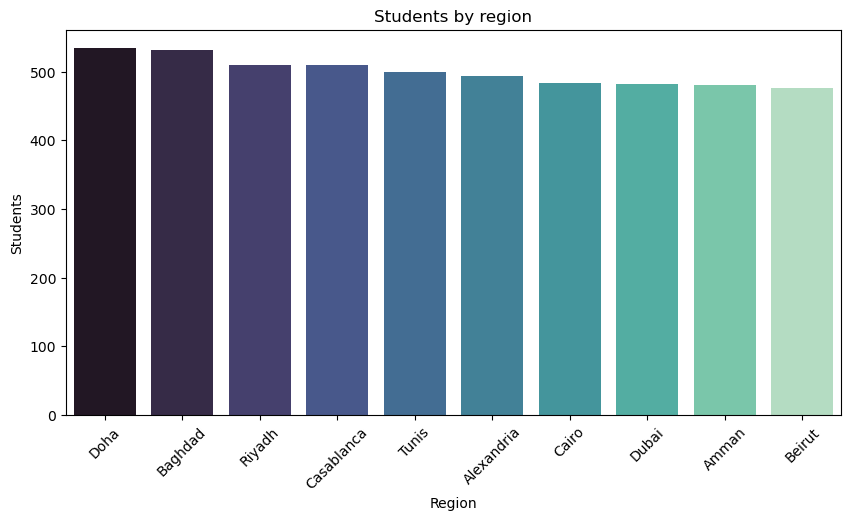

In [16]:
region_distribution = df.groupby(['region'])['region'].count().sort_values(ascending=False).index

plt.figure(figsize=(10,5))

sns.countplot(data=df,
            x="region",
            palette="mako",
            order=region_distribution
)

plt.title("Students by region")
plt.xlabel("Region")
plt.ylabel("Students")
plt.xticks(rotation=45)
plt.show()

- Note: The distribution between region is almost even.

In [17]:
cohorte = df.groupby(['enroll_date'])['student_id'].count().sort_values()

print(cohorte)

enroll_date
2024-07-19     5
2024-09-13     5
2024-12-08     6
2024-04-16     6
2024-07-01     7
              ..
2024-10-19    21
2024-07-10    22
2024-08-20    23
2024-07-31    23
2024-12-04    23
Name: student_id, Length: 365, dtype: int64


- Note: There are 365 different cohorts according to the enrollment date.

In [18]:
# Show students enrolled by month
enroll_by_month = df.groupby(['month'])['student_id'].count()
print(enroll_by_month)

month
1     390
2     430
3     421
4     388
5     418
6     436
7     418
8     451
9     388
10    422
11    386
12    452
Name: student_id, dtype: int64


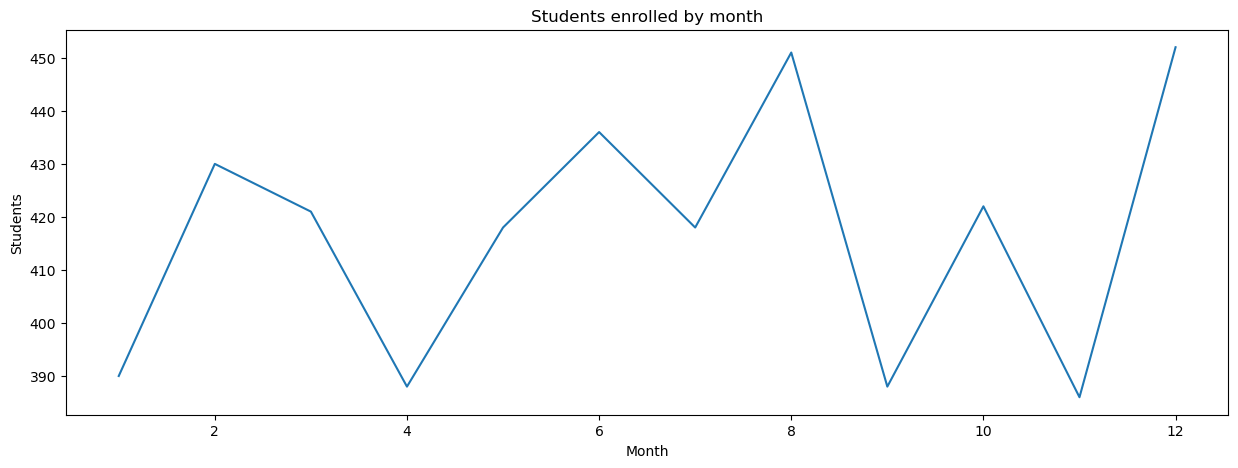

In [19]:
# Plot enrolled by month
plt.figure(figsize=(15,5))

sns.lineplot(x=enroll_by_month.index,
             y=enroll_by_month.values            
)

plt.title("Students enrolled by month")
plt.xlabel('Month')
plt.ylabel('Students')
plt.show()

- Note: Monthly enrollments can be divided into three groups; months 1, 4, 9 and 11 register the lowest enrollments, followed by months with an increasing number such as 3, 5, 7 and 10; finally, months 2, 6, 8 and 12 register the highest enrollments.

In [20]:
# Students actual status
status = df.groupby('label_name')['student_id'].count()
status_percentage = status/status.sum()*100
print(status)
print(status_percentage)

label_name
active     1704
at-risk    1663
dropped    1633
Name: student_id, dtype: int64
label_name
active     34.08
at-risk    33.26
dropped    32.66
Name: student_id, dtype: float64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_18068\3053278714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


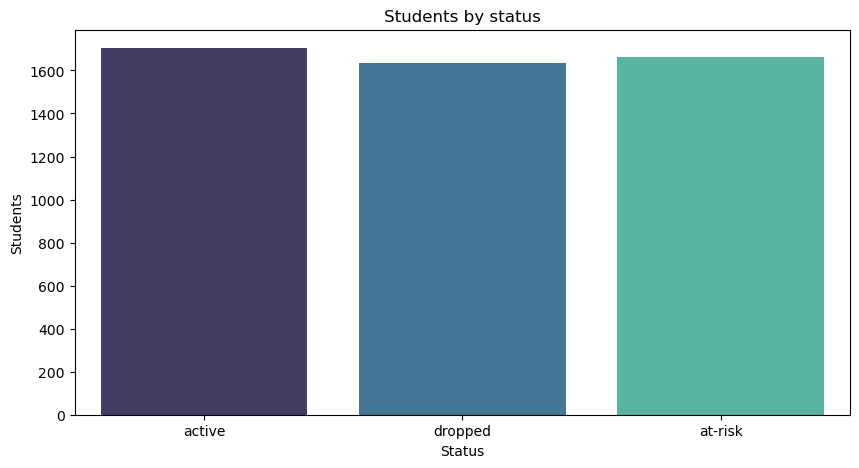

In [21]:
# Plot students by status
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='label_name',
    palette="mako"
)

plt.title("Students by status")
plt.xlabel("Status")
plt.ylabel("Students")
plt.show()

- Note: Distribution between students status are almost even.

In [22]:
# Summary students by age
print(df['age'].describe())

count    5000.000000
mean       23.736600
std         4.583211
min        17.000000
25%        20.000000
50%        24.000000
75%        27.000000
max        40.000000
Name: age, dtype: float64


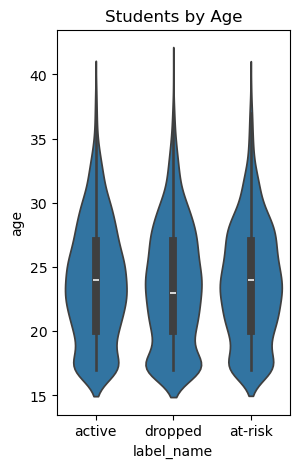

In [23]:
# Plot students by age
plt.figure(figsize=(3,5))

sns.violinplot(
    data=df,
    x="label_name",
    y="age"
)

plt.title("Students by Age")
plt.show()

- Note: The youngest student in the dataset is 17 years old, while the oldest is 40 years old. The average students is 23 years old.

C:\Users\Pablo\AppData\Local\Temp\ipykernel_18068\152883742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


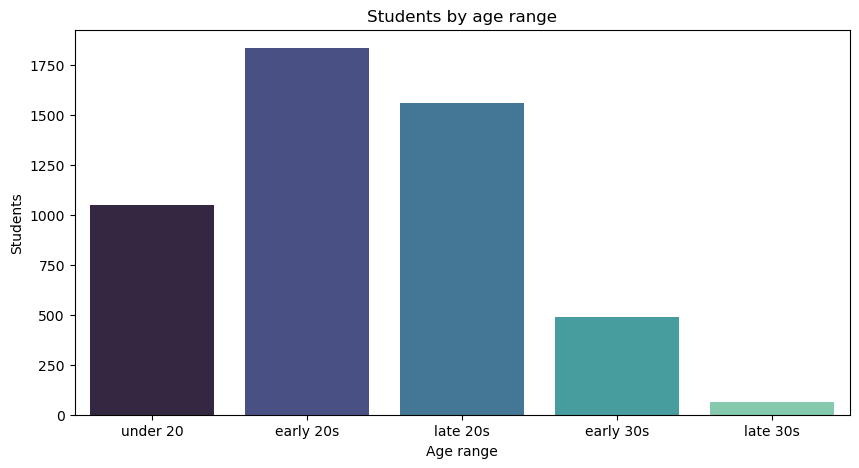

In [24]:
# Plot students by age range
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='age_range',
    palette="mako",
    order=['under 20','early 20s', 'late 20s', 'early 30s', 'late 30s']
)

plt.title("Students by age range")
plt.xlabel("Age range")
plt.ylabel("Students")
plt.show()

Note: To facilitate visualization of the age classification, students are divided into 5-year intervals. The vast majority of students are between 20 and 30 years old.

In [25]:
# Counts students' status by region
status_by_region = pd.pivot_table(df,'student_id',index='region', columns='label_name', aggfunc='count')
print(status_by_region)
# Show students by region as percentage
percentage_by_region = status_by_region.div(status_by_region.sum(axis=1), axis=0) * 100

print(percentage_by_region)

label_name  active  at-risk  dropped
region                              
Alexandria     193      157      143
Amman          172      155      154
Baghdad        185      168      179
Beirut         146      158      172
Cairo          168      153      163
Casablanca     157      172      180
Doha           163      190      181
Dubai          170      156      156
Riyadh         188      167      155
Tunis          162      187      150
label_name     active    at-risk    dropped
region                                     
Alexandria  39.148073  31.845842  29.006085
Amman       35.758836  32.224532  32.016632
Baghdad     34.774436  31.578947  33.646617
Beirut      30.672269  33.193277  36.134454
Cairo       34.710744  31.611570  33.677686
Casablanca  30.844794  33.791749  35.363458
Doha        30.524345  35.580524  33.895131
Dubai       35.269710  32.365145  32.365145
Riyadh      36.862745  32.745098  30.392157
Tunis       32.464930  37.474950  30.060120


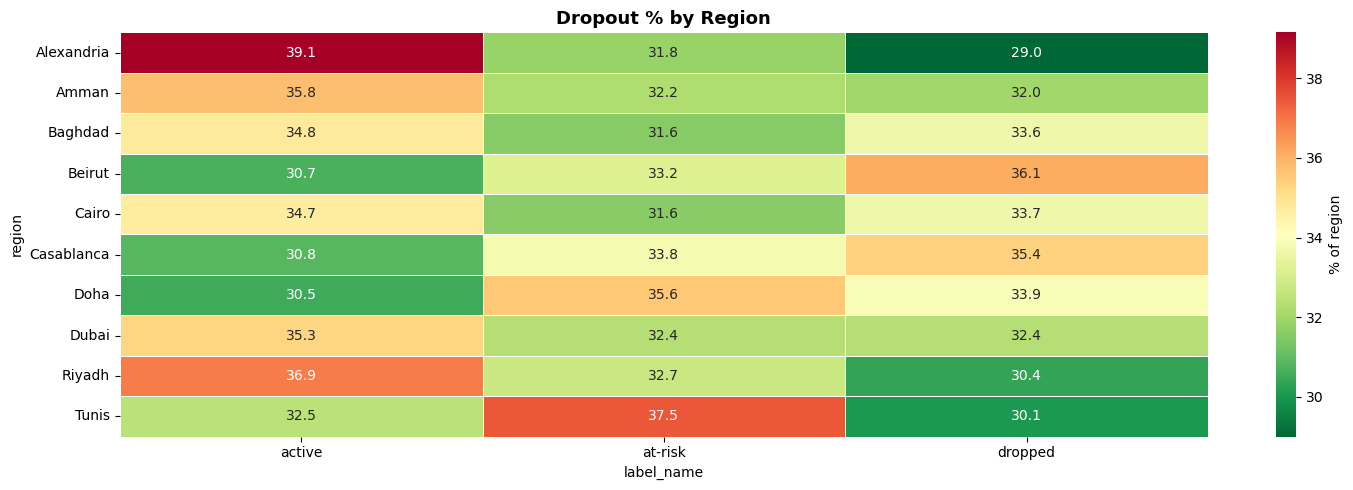

In [26]:
# Plot students by region heatmap
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(percentage_by_region, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".1f",
            linewidths=0.5, cbar_kws={"label": "% of region"})
ax.set_title("Dropout % by Region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

- Note: There's no high difference students dropping out between regions however Beirut, Casablanca and Doha are the top three regions

In [27]:
# Show the average student by label
numeric =['age','exam_season', 'courses_enrolled', 'completed_assignments', 'completion_rate', 'login_frequency', 'last_activity_days_ago', 'forum_posts_count', 'dropout_score', 'label_multiclass']
behavior_label = df.groupby('label_name')[numeric].mean().round(2)

print(behavior_label)

              age  exam_season  courses_enrolled  completed_assignments  \
label_name                                                                
active      23.86         0.06              3.99                  10.21   
at-risk     23.82         0.09              3.98                   3.48   
dropped     23.53         0.14              4.03                   1.68   

            completion_rate  login_frequency  last_activity_days_ago  \
label_name                                                             
active                 0.51             6.67                    8.23   
at-risk                0.18             2.71                    9.02   
dropped                0.09             0.86                   10.87   

            forum_posts_count  dropout_score  label_multiclass  
label_name                                                      
active                   7.98           0.13               0.0  
at-risk                  3.26           0.45               1.0  
dro

-Note: The students who dropped out have a higher exam season, were enrolled in more courses but their rate in completed less assignments, login frequency and forum post is lower than the other students and theirs period of last activity is longer.

## Prepation before modeling

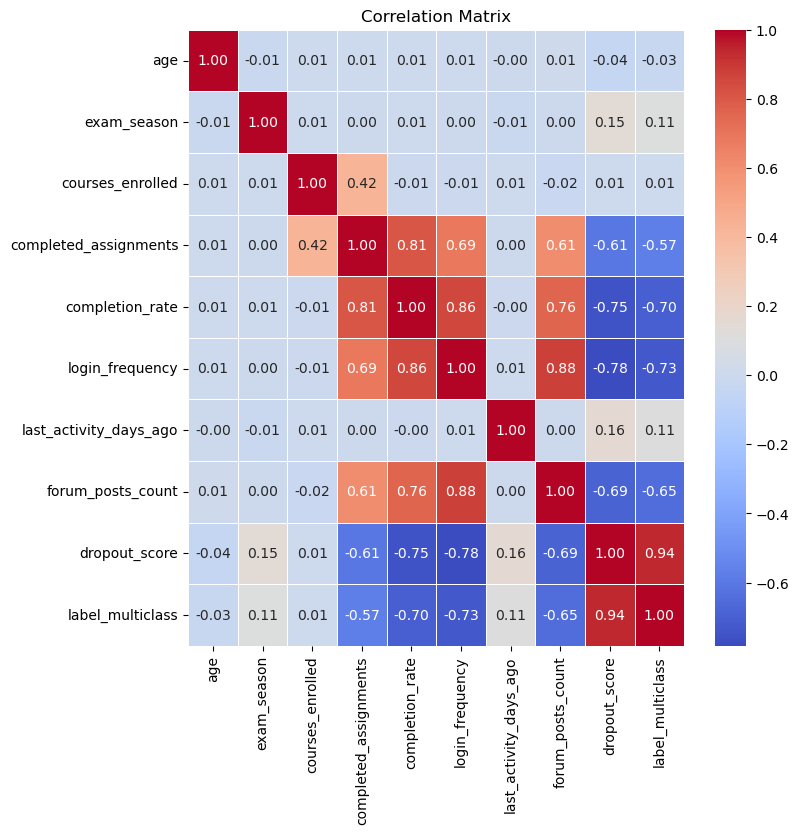

In [28]:
# Plot correlation heatmap
corr = df[numeric].corr()

plt.figure(figsize=(8,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5
)

plt.title('Correlation Matrix')
plt.show()

In [29]:
# Sort features by correlation importance
features_corr = corr['label_multiclass'].drop('label_multiclass').sort_values(key=abs, ascending=False)
print(features_corr.to_string())

dropout_score             0.938563
login_frequency          -0.732079
completion_rate          -0.704463
forum_posts_count        -0.645485
completed_assignments    -0.573028
last_activity_days_ago    0.113803
exam_season               0.106283
age                      -0.028996
courses_enrolled          0.006983


- Note: The top correlated variables are login_frequency, completion_rate, forum_posts_count, completed_assignments.

label
1    0.6592
0    0.3408
Name: proportion, dtype: float64


<Axes: xlabel='label'>

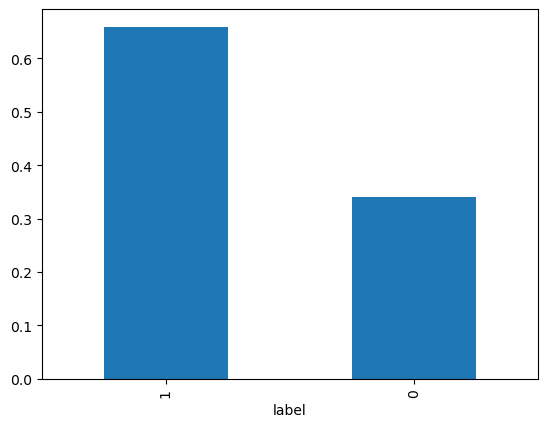

In [30]:
# Count the frequency to measure the imbalance
class_frequency = df['label'].value_counts(normalize=True)
print(class_frequency)
class_frequency.plot(kind='bar')

- Note: When the dataset is divided by a binary classification the distribution changes beeing students who dropout only 1/3 of total students.

## Modeling

In [31]:
# Drop irrelevant features
print(df.columns)
print()

df_new = df.drop(['student_id', 'enroll_date','dropout_score', 'label_name','label_multiclass', 'year'], axis=1)
print("Columns deleted")
print(df_new.info())

Index(['student_id', 'age', 'region', 'enroll_date', 'exam_season',
       'courses_enrolled', 'completed_assignments', 'completion_rate',
       'login_frequency', 'last_activity_days_ago', 'forum_posts_count',
       'dropout_score', 'label', 'label_multiclass', 'label_name', 'year',
       'month', 'day', 'age_range'],
      dtype='object')

Columns deleted
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   region                  5000 non-null   object 
 2   exam_season             5000 non-null   int64  
 3   courses_enrolled        5000 non-null   int64  
 4   completed_assignments   5000 non-null   int64  
 5   completion_rate         5000 non-null   float64
 6   login_frequency         5000 non-null   float64
 7   last_activity_days_ago  5000 non-null   int64  


In [32]:
# Transform categorical features into numerical ones
data_ohe = pd.get_dummies(df_new, drop_first=True)
print(data_ohe.head(3))

   age  exam_season  courses_enrolled  completed_assignments  completion_rate  \
0   26            0                 3                      5           0.3571   
1   23            0                 6                      0           0.0000   
2   17            0                 3                      1           0.0435   

   login_frequency  last_activity_days_ago  forum_posts_count  label  month  \
0             5.29                      10                  5      0      1   
1             0.84                       7                  0      1      5   
2             1.79                      36                  0      1      3   

   ...  region_Cairo  region_Casablanca  region_Doha  region_Dubai  \
0  ...         False              False        False         False   
1  ...         False              False        False         False   
2  ...         False              False        False          True   

   region_Riyadh  region_Tunis  age_range_early 30s  age_range_late 20s  \
0 

In [33]:
# Fix new columns names
print(data_ohe.columns)
print()

data_ohe.columns = data_ohe.columns.str.replace(" ", "_")
print("Fix applied")
print(data_ohe.columns)

Index(['age', 'exam_season', 'courses_enrolled', 'completed_assignments',
       'completion_rate', 'login_frequency', 'last_activity_days_ago',
       'forum_posts_count', 'label', 'month', 'day', 'region_Amman',
       'region_Baghdad', 'region_Beirut', 'region_Cairo', 'region_Casablanca',
       'region_Doha', 'region_Dubai', 'region_Riyadh', 'region_Tunis',
       'age_range_early 30s', 'age_range_late 20s', 'age_range_late 30s',
       'age_range_under 20'],
      dtype='object')

Fix applied
Index(['age', 'exam_season', 'courses_enrolled', 'completed_assignments',
       'completion_rate', 'login_frequency', 'last_activity_days_ago',
       'forum_posts_count', 'label', 'month', 'day', 'region_Amman',
       'region_Baghdad', 'region_Beirut', 'region_Cairo', 'region_Casablanca',
       'region_Doha', 'region_Dubai', 'region_Riyadh', 'region_Tunis',
       'age_range_early_30s', 'age_range_late_20s', 'age_range_late_30s',
       'age_range_under_20'],
      dtype='object')


In [34]:
# Divide the features and the target
features = data_ohe.drop(['label',],axis=1)
target = data_ohe['label']

# Divide the data for training and validation
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=12345)

print(f'Train: {features_train.shape}')
print(f'Test: {features_test.shape}')

Train: (3750, 23)
Test: (1250, 23)


In [35]:
# ===============================
# Evaluation function
# ===============================

def evaluate_model(model, features_train, target_train, cv, model_name, param_name, param_value, scale=False):
    """
    Evaluate a model using cross validation.

    Parameters
    ----------
    model           : Sklearn model with hyperparameters wanted
    features_train  : features from training set
    target_train    : target from training set
    cv              : object StratifiedFold
    model_name      : Model name that will be printed
    param_name      : Hyperparameter that will be changing
    param_value     : Hyperparameter value
    scale           : Bool - if True aplply StandardScaler within the fold

    Return
    ----------
    dict with average metrics
    """
    # Header
    print(f"\n{model_name} ({param_name}: {param_value})")     
    print("="*65)

    # Empty lists for results
    acc_scores, prec_scores, rec_scores, f1_scores, auc_scores = [], [], [], [], []

    # Cross validation by fold
    for fold, (train_idx, val_idx) in enumerate(cv.split(features_train, target_train), 1):
        X_train = features_train.iloc[train_idx]
        X_val   = features_train.iloc[val_idx]
        y_train = target_train.iloc[train_idx]
        y_val   = target_train.iloc[val_idx]

        # Scale within the fold to prevent leakage
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train) # Fit only train set
            X_val   = scaler.transform(X_val)       # Transform in validation
        
        # Train model
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        probs = np.array(model.predict_proba(X_val))[:, 1].ravel()

        # Metrics by iteración
        acc  = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds)
        rec  = recall_score(y_val, preds, zero_division=0)
        f1   = f1_score(y_val, preds, zero_division=0)
        auc  = roc_auc_score(y_val, probs)

        # Append results to lists
        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)
        auc_scores.append(auc)

        print(f"Fold {fold} | Acc: {acc:.3f} | Prec: {prec:.3f} | "
              f"Rec: {rec:.3f} | F1: {f1:.3f} | AUROC: {auc:.3f}")
    means = {
        'acc' : np.mean(acc_scores),
        'prec' : np.mean(prec_scores),
        'rec' : np.mean(rec_scores),
        'f1' : np.mean(f1_scores),
        'auc' : np.mean(auc_scores),
    }

    print(f"\n Average ({param_name}={param_value})")
    print(f"\n Accuracy  : {means['acc']:.4f}")
    print(f"\n Precision : {means['prec']:.4f}")
    print(f"\n Recall    : {means['rec']:.4f}")
    print(f"\n F1        : {means['f1']:.4f}")
    print(f"\n AU-ROC    : {means['auc']:.4f}")

    return means


In [36]:
# ===============================
# Best result function
# ===============================

def find_best(results, param_name):
    """
    Print best model measure by AU-ROC
    """
    best = max(results, key=lambda r: r['auc'])
    print("\n" + "="*65)
    print("\n Best setup:")
    print(f" {param_name} : {best[param_name]}")
    print(f" Mean Accuracy : {best['acc']:.4f}")
    print(f" Best AU-ROC : {best['auc']:.4f}")
    return best

In [37]:
# ===============================
# Cross validation
# ===============================

# Only features_train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12345)

In [38]:
# Logistic Regression
print("\n Logistic Regression ")

# Empty list for results
lr_results = []
# Bucle for hyperparameter
for iteration in [100,200]:
    # Define model
    model = LogisticRegression(
        random_state=12345,
        max_iter=iteration,
        solver='lbfgs'
    )
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="LogisticRegression", param_name="max_iter",
        param_value=iteration, scale=True
    )
    # Select results of hyperparameter
    means['max_iter'] = iteration
    # Gather results
    lr_results.append(means)

best_lr = find_best(lr_results, 'max_iter')


 Logistic Regression 

LogisticRegression (max_iter: 100)
Fold 1 | Acc: 0.900 | Prec: 0.905 | Rec: 0.947 | F1: 0.926 | AUROC: 0.967
Fold 2 | Acc: 0.900 | Prec: 0.915 | Rec: 0.935 | F1: 0.925 | AUROC: 0.964
Fold 3 | Acc: 0.901 | Prec: 0.923 | Rec: 0.927 | F1: 0.925 | AUROC: 0.963
Fold 4 | Acc: 0.915 | Prec: 0.909 | Rec: 0.968 | F1: 0.937 | AUROC: 0.969
Fold 5 | Acc: 0.891 | Prec: 0.900 | Rec: 0.937 | F1: 0.918 | AUROC: 0.955

 Average (max_iter=100)

 Accuracy  : 0.9013

 Precision : 0.9104

 Recall    : 0.9428

 F1        : 0.9262

 AU-ROC    : 0.9635

LogisticRegression (max_iter: 200)
Fold 1 | Acc: 0.900 | Prec: 0.905 | Rec: 0.947 | F1: 0.926 | AUROC: 0.967
Fold 2 | Acc: 0.900 | Prec: 0.915 | Rec: 0.935 | F1: 0.925 | AUROC: 0.964
Fold 3 | Acc: 0.901 | Prec: 0.923 | Rec: 0.927 | F1: 0.925 | AUROC: 0.963
Fold 4 | Acc: 0.915 | Prec: 0.909 | Rec: 0.968 | F1: 0.937 | AUROC: 0.969
Fold 5 | Acc: 0.891 | Prec: 0.900 | Rec: 0.937 | F1: 0.918 | AUROC: 0.955

 Average (max_iter=200)

 Accuracy

In [39]:
# Decision Tree
print("\n Decision Tree ")

# Empty list for results
tree_results = []
# Bucle for hyperparameter
for depth in [6,7,8]:
    # Define model
    model = DecisionTreeClassifier(
        random_state=12345,
        max_depth=depth
    )
    # Evaluate model
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="DecisionTreeClassifier", param_name="max_depth",
        param_value=depth, scale=False
    )
    # Select results of hyperparameter
    means['max_depth'] = depth
    # Gather results
    tree_results.append(means)

best_tree = find_best(tree_results, 'max_depth')


 Decision Tree 

DecisionTreeClassifier (max_depth: 6)
Fold 1 | Acc: 0.912 | Prec: 0.948 | Rec: 0.917 | F1: 0.932 | AUROC: 0.963
Fold 2 | Acc: 0.917 | Prec: 0.934 | Rec: 0.941 | F1: 0.937 | AUROC: 0.966
Fold 3 | Acc: 0.909 | Prec: 0.922 | Rec: 0.941 | F1: 0.932 | AUROC: 0.955
Fold 4 | Acc: 0.925 | Prec: 0.915 | Rec: 0.978 | F1: 0.945 | AUROC: 0.974
Fold 5 | Acc: 0.897 | Prec: 0.895 | Rec: 0.955 | F1: 0.924 | AUROC: 0.942

 Average (max_depth=6)

 Accuracy  : 0.9123

 Precision : 0.9227

 Recall    : 0.9464

 F1        : 0.9341

 AU-ROC    : 0.9601

DecisionTreeClassifier (max_depth: 7)
Fold 1 | Acc: 0.912 | Prec: 0.944 | Rec: 0.921 | F1: 0.932 | AUROC: 0.964
Fold 2 | Acc: 0.895 | Prec: 0.940 | Rec: 0.897 | F1: 0.918 | AUROC: 0.953
Fold 3 | Acc: 0.905 | Prec: 0.934 | Rec: 0.921 | F1: 0.927 | AUROC: 0.949
Fold 4 | Acc: 0.935 | Prec: 0.922 | Rec: 0.984 | F1: 0.952 | AUROC: 0.974
Fold 5 | Acc: 0.888 | Prec: 0.906 | Rec: 0.925 | F1: 0.915 | AUROC: 0.934

 Average (max_depth=7)

 Accuracy  

In [40]:
# Random Forest
print("\n Random Forest ")

# Empty list for results
forest_results = []
# Bucle for hyperparameter
for estimators in [50,100,150]:
    # Define model
    model = RandomForestClassifier(
        random_state=12345,
        max_depth = best_tree['max_depth'],
        n_estimators=estimators
    )
    # Evaluate model
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="RandomForestClassifier", param_name="n_estimators",
        param_value=estimators, scale=False
    )
    # Select results of hyperparameter
    means['n_estimators'] = estimators
    # Gather results
    forest_results.append(means)

best_forest = find_best(forest_results, 'n_estimators')


 Random Forest 

RandomForestClassifier (n_estimators: 50)
Fold 1 | Acc: 0.920 | Prec: 0.916 | Rec: 0.968 | F1: 0.941 | AUROC: 0.981
Fold 2 | Acc: 0.923 | Prec: 0.936 | Rec: 0.947 | F1: 0.942 | AUROC: 0.975
Fold 3 | Acc: 0.917 | Prec: 0.927 | Rec: 0.949 | F1: 0.938 | AUROC: 0.974
Fold 4 | Acc: 0.932 | Prec: 0.915 | Rec: 0.988 | F1: 0.950 | AUROC: 0.978
Fold 5 | Acc: 0.893 | Prec: 0.892 | Rec: 0.953 | F1: 0.921 | AUROC: 0.969

 Average (n_estimators=50)

 Accuracy  : 0.9171

 Precision : 0.9170

 Recall    : 0.9610

 F1        : 0.9384

 AU-ROC    : 0.9755

RandomForestClassifier (n_estimators: 100)
Fold 1 | Acc: 0.920 | Prec: 0.917 | Rec: 0.966 | F1: 0.941 | AUROC: 0.979
Fold 2 | Acc: 0.925 | Prec: 0.938 | Rec: 0.949 | F1: 0.944 | AUROC: 0.974
Fold 3 | Acc: 0.919 | Prec: 0.929 | Rec: 0.949 | F1: 0.939 | AUROC: 0.975
Fold 4 | Acc: 0.932 | Prec: 0.917 | Rec: 0.986 | F1: 0.950 | AUROC: 0.977
Fold 5 | Acc: 0.897 | Prec: 0.897 | Rec: 0.953 | F1: 0.924 | AUROC: 0.969

 Average (n_estimators

In [41]:
# Gradient Boosting
print("\n Gradient Boosting ")

# Empty list for results
gboost_results = []
# Bucle for hyperparameter
for estimators in [50,100,150]:
    # Define model
    model = GradientBoostingClassifier(
        random_state=12345,
        max_depth = 4,
        n_estimators=estimators,
        learning_rate=0.1,
        loss='log_loss'
    )
    # Evaluate model
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="GradientBoostingClassifier", param_name="n_estimators",
        param_value=estimators, scale=False
    )
    # Select results of hyperparameter
    means['n_estimators'] = estimators
    # Gather results
    gboost_results.append(means)

best_gboost = find_best(gboost_results, 'n_estimators')


 Gradient Boosting 

GradientBoostingClassifier (n_estimators: 50)
Fold 1 | Acc: 0.923 | Prec: 0.921 | Rec: 0.966 | F1: 0.943 | AUROC: 0.984
Fold 2 | Acc: 0.925 | Prec: 0.947 | Rec: 0.939 | F1: 0.943 | AUROC: 0.980
Fold 3 | Acc: 0.921 | Prec: 0.936 | Rec: 0.945 | F1: 0.940 | AUROC: 0.977
Fold 4 | Acc: 0.939 | Prec: 0.936 | Rec: 0.974 | F1: 0.954 | AUROC: 0.986
Fold 5 | Acc: 0.900 | Prec: 0.902 | Rec: 0.951 | F1: 0.926 | AUROC: 0.969

 Average (n_estimators=50)

 Accuracy  : 0.9216

 Precision : 0.9281

 Recall    : 0.9549

 F1        : 0.9412

 AU-ROC    : 0.9793

GradientBoostingClassifier (n_estimators: 100)
Fold 1 | Acc: 0.919 | Prec: 0.925 | Rec: 0.953 | F1: 0.939 | AUROC: 0.985
Fold 2 | Acc: 0.915 | Prec: 0.946 | Rec: 0.923 | F1: 0.934 | AUROC: 0.980
Fold 3 | Acc: 0.924 | Prec: 0.943 | Rec: 0.941 | F1: 0.942 | AUROC: 0.978
Fold 4 | Acc: 0.941 | Prec: 0.941 | Rec: 0.972 | F1: 0.956 | AUROC: 0.987
Fold 5 | Acc: 0.901 | Prec: 0.908 | Rec: 0.945 | F1: 0.926 | AUROC: 0.968

 Average (

In [42]:
# ===============================
# Comparison between models
# ===============================

print("\n\n" + "=" * 65)
print("Comparison Summary (AU-ROC with cross validation)")
print("=" * 65)
 
summary = [
    ("Logistic Regression", best_lr),
    ("Decision Tree",       best_tree),
    ("Random Forest",       best_forest),
    ("Gradient Boosting",   best_gboost),
]
 
for name, result in sorted(summary, key=lambda x: x[1]['auc'], reverse=True):
    print(f"  {name:<25} AU-ROC: {result['auc']:.4f} | F1: {result['f1']:.4f}")



Comparison Summary (AU-ROC with cross validation)
  Gradient Boosting         AU-ROC: 0.9794 | F1: 0.9396
  Random Forest             AU-ROC: 0.9755 | F1: 0.9384
  Logistic Regression       AU-ROC: 0.9635 | F1: 0.9262
  Decision Tree             AU-ROC: 0.9601 | F1: 0.9341


- Note: Gradient Boosting model has the higher performance at predicting droppingout students while Descision Tree has the lower performance. The result is a bit curious due Logistic Regression model is usually the benchmark for other models, this result can be attributed to the chosen hyperparameter chosen to iterate.

## Conclusions

- The dataset quality is reliable, as it contains no missing or duplicate values ​​and is balanced across regions and classes.

- Exploratory data analysis (EDA) offers some interesting insights:
    - Some months have low enrollment, others show an increase, and still others have even higher enrollment; the reasons for this can be studied later.
    - The vast majority of students are between 20 and 30 years old.
    - Students who dropped out had a more intense exam period and enrolled in more courses, but their assignment completion rate, login frequency, and forum participation are lower than those of other students, and their period of last activity is longer.
    - The variables with the highest correlation are login frequency, completion rate, number of forum posts, and completed assignments.

- Since the models predict a binary classification and the data are unbalanced across classes, the metric chosen to evaluate the model is AU-ROC.